In [1]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.converters import circuit_to_dag,dag_to_circuit

import sys
sys.path.append("../")
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, transform_qiskit_to_stim,generate_qiskit_param_map
import testing_scripts.graphs_utils as graphs_utils 
from testing_scripts.qaoa_utils import QAOASolver
import red_qaoa.red_qaoa as red_qaoa

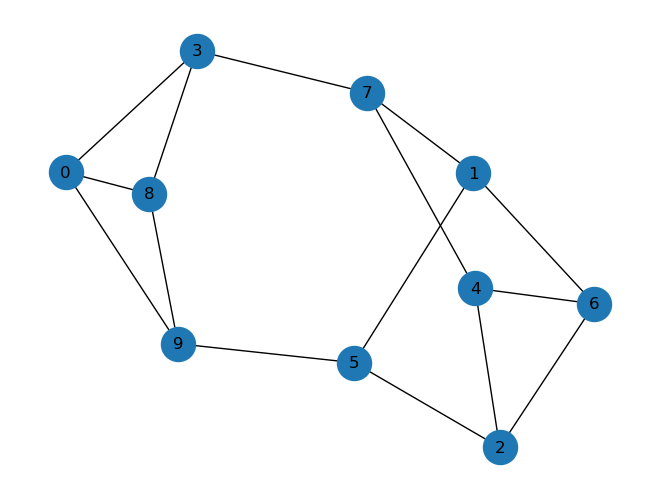

In [2]:
n =10
k=3

G = graphs_utils.generate_k_regular_graph(num_vertices=n, k=k, weighted=True,seed=0)
# G=graphs_utils.generate_random_complete_graph(num_vertices=n, weighted=False, seed=2)
# G = graphs_utils.generate_random_ego_graph(num_vertices=n,weighted=False,seed=2)
# G = graphs_utils.generate_random_erdos_renyi_graph(num_nodes=n,probability=0.4,weighted=False,seed=4)
draw_graph(G, node_size=600, with_labels=True)

In [3]:
#The reduced rustworkx graph 
nx_graph = graphs_utils.rustworkx_to_networkx(G)
red_nx_graph = red_qaoa.red_qaoa_exe(nx_graph)
red_G = graphs_utils.networkx_to_rustworkx(red_nx_graph)

In [4]:
max_cut_paulis = graphs_utils.build_max_cut_paulis(red_G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)
print(f"Number of terms : {len(cost_hamiltonian)}")

Cost Function Hamiltonian: SparsePauliOp(['IIIZIIZ', 'IIZIIIZ', 'IIIIZZI', 'IZIIIZI', 'IZIIZII', 'ZIIIZII', 'IIZZIII', 'ZIZIIII'],
              coeffs=[1.+0.j, 1.+0.j, 3.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])
Number of terms : 8


In [5]:
reps = 2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)

In [6]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
red_solver = QAOASolver(cost_hamiltonian,circuit.decompose().decompose(),sim_device="CPU")
red_solver.vanilla = True

In [7]:
x0 = np.random.rand(reps * 2) * np.pi
res,obj_values=red_solver.run_qaoa(x0, max_iters=10**3)
results_dict = {
    "vanilla_fin_energy": res,
    "vanilla_iteration_values": obj_values,
}

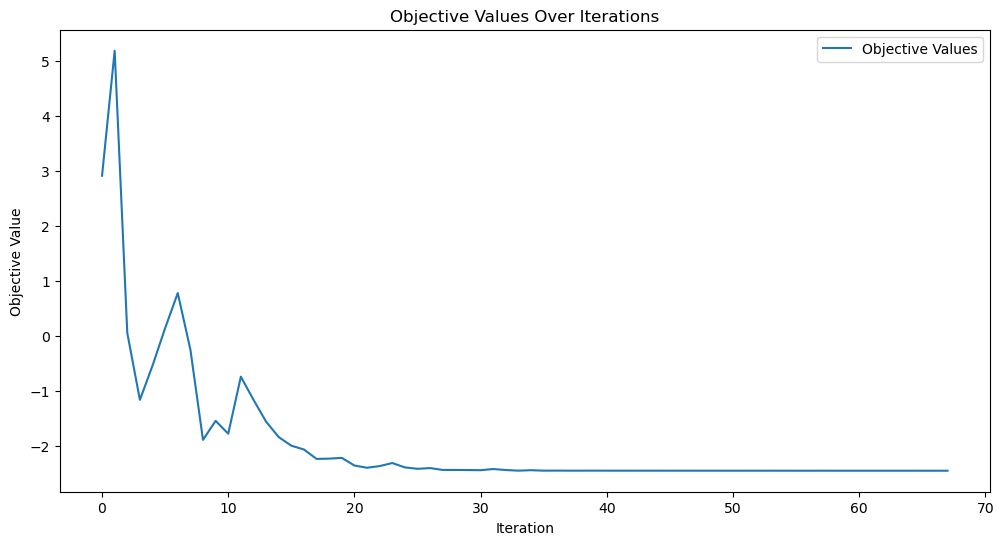

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(obj_values, label="Objective Values")
plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Objective Values Over Iterations")
plt.legend()
plt.show()

In [9]:
best_red_params = res.x

In [10]:
# Evaluated on Original Graph
max_cut_paulis = graphs_utils.build_max_cut_paulis(G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)
print(f"Number of terms : {len(cost_hamiltonian)}")

Cost Function Hamiltonian: SparsePauliOp(['IIIIZIIZII', 'IIIZIIIIZI', 'ZIIIZIIIII', 'IIIIIZIZII', 'IIZIIIIIZI', 'IIIIIIZIIZ', 'IIZIIIZIII', 'IIIZIIIZII', 'IIZIIZIIII', 'IIIIZIIIZI', 'IZIIIIZIII', 'IIIZIZIIII', 'ZZIIIIIIII', 'ZIIIIIIIIZ', 'IZIIIIIIIZ'],
              coeffs=[ 4.+0.j, 10.+0.j,  1.+0.j,  3.+0.j,  2.+0.j,  4.+0.j,  2.+0.j,  9.+0.j,
 10.+0.j, 10.+0.j,  6.+0.j,  3.+0.j, 10.+0.j,  4.+0.j,  1.+0.j])
Number of terms : 15


In [11]:
reps = 2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)

In [12]:
exact_solver = QAOASolver(cost_hamiltonian,circuit.decompose().decompose(),sim_device="CPU")
exact_solver.vanilla = True

In [13]:
red_qaoa_final_energy = exact_solver.evaluate_energy(exact_solver.circuit,exact_solver.cost_hamiltonian,best_red_params)
red_qaoa_final_energy

array(-8.19776964)

In [14]:
exact_solver.evaluate_exact_energy()

Exact Energy from Eigensolver: -71.0


np.float64(-71.0)